<a href="https://colab.research.google.com/github/infant88/Big_Data_Apache_Spark_ML/blob/main/Big_Data_Apache_Spark_ML_Assignment_question_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡ Machine Learning with Apache Spark

---
**Course Code / Name:** 22CSEDE23 / Big Data Analytics  
**Name:** Infant Preshith P  
**Branch:** CSE GEN B    
**Year / Sem / Section:** III / VI / B  

---

## 📌 Problem Statement: Credit Card Fraud Detection

We solve a **binary classification** problem — detecting fraudulent credit card transactions — using Apache Spark's MLlib. This covers:

| Topic | Coverage |
|---|---|
| Spark Architecture | SparkContext, SparkSession, DAG, Executors |
| RDDs | Creation, Transformations, Actions |
| DataFrames & Spark SQL | Queries, Views, Aggregations |
| MLlib Pipelines | Feature Engineering, Model Training |
| Algorithm Comparison | Logistic Regression, Random Forest, GBT, Decision Tree |
| Hyperparameter Tuning | CrossValidator, ParamGrid |
| Spark Streaming | Simulated real-time fraud detection |
| Evaluation | Accuracy, AUC-ROC, Precision, Recall, F1 |


## ⚙️ Step 1: Install & Configure Apache Spark


In [1]:
import subprocess, sys, os

# ── Install PySpark & findspark if needed ─────────────────────────────────────
subprocess.run([sys.executable, '-m', 'pip', 'install', 'pyspark', 'findspark', '-q'], check=False)

# ── Detect and set JAVA_HOME ─────────────────────────────────────────────────
import shutil

def find_java_home():
    # Try common Colab/Linux paths
    candidates = [
        '/usr/lib/jvm/java-21-openjdk-amd64',
        '/usr/lib/jvm/java-17-openjdk-amd64',
        '/usr/lib/jvm/java-11-openjdk-amd64',
        '/usr/lib/jvm/java-8-openjdk-amd64',
        '/usr/local/lib/jvm/java-11-openjdk-amd64',
    ]
    for path in candidates:
        if os.path.isdir(path):
            return path
    # Use 'java' in PATH to derive JAVA_HOME
    java_path = shutil.which('java')
    if java_path:
        # e.g. /usr/bin/java -> resolve symlinks
        real = os.path.realpath(java_path)
        # walk up to find JAVA_HOME (parent of bin/)
        home = os.path.dirname(os.path.dirname(real))
        if os.path.isdir(home):
            return home
    return None

# Install Java if not present (Colab)
if not shutil.which('java'):
    print('Installing Java...')
    subprocess.run(['apt-get', 'install', '-y', 'openjdk-11-jdk-headless', '-qq'],
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

java_home = find_java_home()
if java_home:
    os.environ['JAVA_HOME'] = java_home
    print(f'✅ JAVA_HOME set to: {java_home}')
else:
    raise EnvironmentError('❌ Java not found. Please install Java 8/11/17/21 first.')

import findspark
findspark.init()

import pyspark
print(f'✅ PySpark version: {pyspark.__version__}')
print(f'✅ Java Home      : {os.environ["JAVA_HOME"]}')


✅ JAVA_HOME set to: /usr/lib/jvm/java-17-openjdk-amd64
✅ PySpark version: 4.0.2
✅ Java Home      : /usr/lib/jvm/java-17-openjdk-amd64


## 🏗️ Step 2: Spark Architecture — SparkContext & SparkSession

```
┌──────────────────────────────────────────────────────┐
│                  SPARK ARCHITECTURE                  │
│                                                      │
│  ┌──────────────┐      ┌────────────────────────┐   │
│  │ Driver Program│      │     Cluster Manager    │   │
│  │ SparkContext  │◄────►│  (YARN / Mesos / Local)│   │
│  └──────┬───────┘      └────────────────────────┘   │
│         │                                            │
│   ┌─────▼──────────────────────────────────────┐    │
│   │              Worker Nodes                  │    │
│   │  ┌──────────┐  ┌──────────┐  ┌──────────┐ │    │
│   │  │ Executor │  │ Executor │  │ Executor │ │    │
│   │  │ Task Task│  │ Task Task│  │ Task Task│ │    │
│   │  └──────────┘  └──────────┘  └──────────┘ │    │
│   └────────────────────────────────────────────┘   │
└──────────────────────────────────────────────────────┘
```


In [2]:
from pyspark.sql import SparkSession
from pyspark import SparkContext, SparkConf

# ── Create SparkSession (entry point for all Spark functionality) ──────────────
spark = SparkSession.builder \
    .appName('FraudDetection_BigData_Assignment') \
    .master('local[*]') \
    .config('spark.executor.memory', '2g') \
    .config('spark.driver.memory', '2g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .config('spark.ui.showConsoleProgress', 'false') \
    .getOrCreate()

sc = spark.sparkContext
sc.setLogLevel('ERROR')

print('=' * 55)
print('  SPARK SESSION DETAILS')
print('=' * 55)
print(f'  App Name   : {sc.appName}')
print(f'  Master     : {sc.master}')
print(f'  Spark Ver  : {sc.version}')
print(f'  Python Ver : {sc.pythonVer}')
print(f'  Default Par: {sc.defaultParallelism}')
print('=' * 55)

  SPARK SESSION DETAILS
  App Name   : FraudDetection_BigData_Assignment
  Master     : local[*]
  Spark Ver  : 4.0.2
  Python Ver : 3.12
  Default Par: 2


## 📂 Step 3: Generate the Fraud Detection Dataset

**Schema** (simulating real credit card transaction data):

| Feature | Type | Description |
|---|---|---|
| transaction_id | int | Unique transaction ID |
| amount | float | Transaction amount (₹) |
| hour | int | Hour of day (0–23) |
| day_of_week | int | Day (0=Mon … 6=Sun) |
| merchant_category | string | Category of merchant |
| distance_from_home | float | km from home location |
| num_prev_transactions | int | Transactions in last 24h |
| avg_amount_7d | float | Avg spend last 7 days |
| is_international | int | 1 = international |
| is_fraud | int | **Label**: 1 = fraud, 0 = genuine |


In [3]:
import random, csv, os
import numpy as np
random.seed(42)
np.random.seed(42)

categories = ['grocery', 'electronics', 'travel', 'restaurant',
              'clothing', 'fuel', 'atm', 'online_retail']

def generate_transaction(txn_id, fraud=False):
    if fraud:
        amount            = round(random.uniform(5000, 150000), 2)
        hour              = random.choice([0, 1, 2, 3, 22, 23])
        distance          = round(random.uniform(200, 2000), 2)
        num_prev          = random.randint(5, 20)
        avg_7d            = round(random.uniform(200, 1000), 2)
        is_international  = random.choice([0, 0, 1, 1, 1])
        category          = random.choice(['electronics', 'travel', 'atm', 'online_retail'])
        dow               = random.randint(0, 6)
    else:
        amount            = round(random.uniform(50, 8000), 2)
        hour              = random.randint(8, 21)
        distance          = round(random.uniform(0, 50), 2)
        num_prev          = random.randint(0, 5)
        avg_7d            = round(random.uniform(500, 5000), 2)
        is_international  = random.choice([0, 0, 0, 1])
        category          = random.choice(categories)
        dow               = random.randint(0, 6)

    return [txn_id, amount, hour, dow, category,
            distance, num_prev, avg_7d, is_international, int(fraud)]

os.makedirs('/tmp/spark_data', exist_ok=True)

N_GENUINE = 9200
N_FRAUD   = 800   # ~8% fraud rate

rows = []
for i in range(1, N_GENUINE + 1):
    rows.append(generate_transaction(i, fraud=False))
for i in range(N_GENUINE + 1, N_GENUINE + N_FRAUD + 1):
    rows.append(generate_transaction(i, fraud=True))

random.shuffle(rows)

header = ['transaction_id','amount','hour','day_of_week','merchant_category',
          'distance_from_home','num_prev_transactions','avg_amount_7d',
          'is_international','is_fraud']

with open('/tmp/spark_data/transactions.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(header)
    writer.writerows(rows)

print(f'✅ Dataset created: {N_GENUINE + N_FRAUD} transactions')
print(f'   Genuine: {N_GENUINE} ({N_GENUINE/(N_GENUINE+N_FRAUD)*100:.1f}%)')
print(f'   Fraud  : {N_FRAUD}   ({N_FRAUD/(N_GENUINE+N_FRAUD)*100:.1f}%)')
print(f'   Location: /tmp/spark_data/transactions.csv')

✅ Dataset created: 10000 transactions
   Genuine: 9200 (92.0%)
   Fraud  : 800   (8.0%)
   Location: /tmp/spark_data/transactions.csv


## 🔷 Step 4: RDDs — Resilient Distributed Datasets

RDDs are the **fundamental data structure** of Spark — immutable, distributed collections.

```
RDD Operations
├── Transformations (lazy) → map, flatMap, filter, reduceByKey, groupByKey
└── Actions (triggers execution) → count, collect, take, reduce, saveAsTextFile
```


In [4]:
# ── RDD Demo ───────────────────────────────────────────────────────────────────

# 1. Create RDD from file
raw_rdd = sc.textFile('/tmp/spark_data/transactions.csv')

# 2. Remove header
header_rdd = raw_rdd.first()
data_rdd   = raw_rdd.filter(lambda line: line != header_rdd)

print(f'✅ Total RDD partitions : {data_rdd.getNumPartitions()}')
print(f'✅ Total records        : {data_rdd.count()}')
print(f'\nSample RDD rows:')
for row in data_rdd.take(3):
    print(' ', row)

# 3. Transformation: Parse CSV → (category, amount) pairs
parsed_rdd = data_rdd.map(lambda line: line.split(',')) \
                     .map(lambda f: (f[4], float(f[1]), int(f[9])))
# (category, amount, is_fraud)

# 4. Filter: Only fraudulent transactions
fraud_rdd = parsed_rdd.filter(lambda x: x[2] == 1)

# 5. ReduceByKey: Total fraud amount per category
fraud_by_cat = fraud_rdd.map(lambda x: (x[0], x[1])) \
                        .reduceByKey(lambda a, b: a + b) \
                        .sortBy(lambda x: -x[1])

print('\n📊 Total Fraud Amount by Merchant Category (RDD):')
print(f'  {"Category":<20}  {"Total Fraud Amount (₹)":>22}')
print('  ' + '-'*46)
for cat, amt in fraud_by_cat.collect():
    print(f'  {cat:<20}  ₹{amt:>20,.2f}')

# 6. AggregateByKey: Count & Sum → Compute Avg
zero_val  = (0.0, 0)
seq_func  = lambda acc, val: (acc[0] + val, acc[1] + 1)
comb_func = lambda a, b: (a[0] + b[0], a[1] + b[1])

avg_by_cat = parsed_rdd.map(lambda x: (x[0], x[1])) \
                       .aggregateByKey(zero_val, seq_func, comb_func) \
                       .mapValues(lambda x: round(x[0]/x[1], 2)) \
                       .sortBy(lambda x: -x[1])

print('\n📊 Average Transaction Amount by Category (RDD aggregateByKey):')
for cat, avg in avg_by_cat.collect():
    print(f'  {cat:<20}  Avg: ₹{avg:>10,.2f}')

✅ Total RDD partitions : 2
✅ Total records        : 10000

Sample RDD rows:
  1667,3724.59,9,6,online_retail,0.34,0,3569.11,1,0
  9530,30127.83,23,2,travel,325.32,12,961.02,0,1
  6444,206.87,14,5,travel,43.69,4,4485.25,1,0

📊 Total Fraud Amount by Merchant Category (RDD):
  Category              Total Fraud Amount (₹)
  ----------------------------------------------
  online_retail         ₹       16,566,729.83
  electronics           ₹       15,955,613.52
  travel                ₹       15,465,692.48
  atm                   ₹       13,896,928.79

📊 Average Transaction Amount by Category (RDD aggregateByKey):
  online_retail         Avg: ₹ 15,533.86
  electronics           Avg: ₹ 15,197.88
  travel                Avg: ₹ 15,157.61
  atm                   Avg: ₹ 13,603.78
  fuel                  Avg: ₹  4,105.44
  grocery               Avg: ₹  4,087.16
  restaurant            Avg: ₹  4,018.00
  clothing              Avg: ₹  3,945.55


In [5]:
# ── RDD Persistence & Lineage ──────────────────────────────────────────────────
from pyspark import StorageLevel

# Persist RDD to avoid recomputation
parsed_rdd.persist(StorageLevel.MEMORY_AND_DISK)

# Count total, fraud, genuine using RDD actions
total   = parsed_rdd.count()
n_fraud = parsed_rdd.filter(lambda x: x[2] == 1).count()
n_legit = parsed_rdd.filter(lambda x: x[2] == 0).count()

print('RDD Persistence Demo')
print(f'  Total Transactions : {total}')
print(f'  Fraudulent         : {n_fraud} ({n_fraud/total*100:.2f}%)')
print(f'  Legitimate         : {n_legit} ({n_legit/total*100:.2f}%)')

# RDD Lineage (DAG)
print('\n📐 RDD Lineage (Debug String):')
print(fraud_by_cat.toDebugString().decode())

RDD Persistence Demo
  Total Transactions : 10000
  Fraudulent         : 800 (8.00%)
  Legitimate         : 9200 (92.00%)

📐 RDD Lineage (Debug String):
(2) PythonRDD[15] at collect at /tmp/ipykernel_796/743084958.py:32 []
 |  MapPartitionsRDD[14] at mapPartitions at PythonRDD.scala:168 []
 |  ShuffledRDD[13] at partitionBy at NativeMethodAccessorImpl.java:0 []
 +-(2) PairwiseRDD[12] at sortBy at /tmp/ipykernel_796/743084958.py:27 []
    |  PythonRDD[11] at sortBy at /tmp/ipykernel_796/743084958.py:27 []
    |  MapPartitionsRDD[8] at mapPartitions at PythonRDD.scala:168 []
    |  ShuffledRDD[7] at partitionBy at NativeMethodAccessorImpl.java:0 []
    +-(2) PairwiseRDD[6] at reduceByKey at /tmp/ipykernel_796/743084958.py:26 []
       |  PythonRDD[5] at reduceByKey at /tmp/ipykernel_796/743084958.py:26 []
       |  /tmp/spark_data/transactions.csv MapPartitionsRDD[1] at textFile at NativeMethodAccessorImpl.java:0 []
       |  /tmp/spark_data/transactions.csv HadoopRDD[0] at textFile at N

## 🗃️ Step 5: Spark DataFrames & Spark SQL


In [6]:
from pyspark.sql import functions as F
from pyspark.sql.types import *

# ── Define Schema ──────────────────────────────────────────────────────────────
schema = StructType([
    StructField('transaction_id',        IntegerType(), True),
    StructField('amount',                FloatType(),   True),
    StructField('hour',                  IntegerType(), True),
    StructField('day_of_week',           IntegerType(), True),
    StructField('merchant_category',     StringType(),  True),
    StructField('distance_from_home',    FloatType(),   True),
    StructField('num_prev_transactions', IntegerType(), True),
    StructField('avg_amount_7d',         FloatType(),   True),
    StructField('is_international',      IntegerType(), True),
    StructField('is_fraud',              IntegerType(), True),
])

# ── Load CSV into DataFrame ───────────────────────────────────────────────────
df = spark.read.csv(
    '/tmp/spark_data/transactions.csv',
    header=True,
    schema=schema
)

df.cache()

print('✅ DataFrame loaded')
df.printSchema()
print(f'Rows: {df.count()}  |  Columns: {len(df.columns)}')
df.show(5, truncate=False)

✅ DataFrame loaded
root
 |-- transaction_id: integer (nullable = true)
 |-- amount: float (nullable = true)
 |-- hour: integer (nullable = true)
 |-- day_of_week: integer (nullable = true)
 |-- merchant_category: string (nullable = true)
 |-- distance_from_home: float (nullable = true)
 |-- num_prev_transactions: integer (nullable = true)
 |-- avg_amount_7d: float (nullable = true)
 |-- is_international: integer (nullable = true)
 |-- is_fraud: integer (nullable = true)

Rows: 10000  |  Columns: 10
+--------------+--------+----+-----------+-----------------+------------------+---------------------+-------------+----------------+--------+
|transaction_id|amount  |hour|day_of_week|merchant_category|distance_from_home|num_prev_transactions|avg_amount_7d|is_international|is_fraud|
+--------------+--------+----+-----------+-----------------+------------------+---------------------+-------------+----------------+--------+
|1667          |3724.59 |9   |6          |online_retail    |0.34      

In [7]:
# ── Spark SQL Queries ─────────────────────────────────────────────────────────
df.createOrReplaceTempView('transactions')

print('=== SQL 1: Class Distribution ===')
spark.sql("""
    SELECT is_fraud,
           COUNT(*) AS count,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER(), 2) AS percentage
    FROM transactions
    GROUP BY is_fraud
    ORDER BY is_fraud
""").show()

print('=== SQL 2: Fraud Rate by Merchant Category ===')
spark.sql("""
    SELECT merchant_category,
           COUNT(*) AS total_txns,
           SUM(is_fraud) AS fraud_count,
           ROUND(AVG(is_fraud) * 100, 2) AS fraud_rate_pct,
           ROUND(AVG(amount), 2) AS avg_amount,
           ROUND(MAX(amount), 2) AS max_amount
    FROM transactions
    GROUP BY merchant_category
    ORDER BY fraud_rate_pct DESC
""").show()

print('=== SQL 3: Fraud by Hour of Day ===')
spark.sql("""
    SELECT hour,
           SUM(is_fraud) AS fraud_count,
           COUNT(*) AS total,
           ROUND(AVG(is_fraud)*100, 2) AS fraud_rate_pct
    FROM transactions
    GROUP BY hour
    ORDER BY fraud_rate_pct DESC
    LIMIT 8
""").show()

print('=== SQL 4: High Risk Transactions (SQL Window Function) ===')
spark.sql("""
    SELECT * FROM (
        SELECT transaction_id, merchant_category, amount, distance_from_home, is_fraud,
               RANK() OVER (PARTITION BY merchant_category ORDER BY amount DESC) AS rank_in_cat
        FROM transactions
        WHERE is_fraud = 1
    ) ranked
    WHERE rank_in_cat <= 2
    ORDER BY merchant_category, amount DESC
""").show(20, truncate=False)

=== SQL 1: Class Distribution ===
+--------+-----+----------+
|is_fraud|count|percentage|
+--------+-----+----------+
|       0| 9200|     92.00|
|       1|  800|      8.00|
+--------+-----+----------+

=== SQL 2: Fraud Rate by Merchant Category ===
+-----------------+----------+-----------+--------------+----------+----------+
|merchant_category|total_txns|fraud_count|fraud_rate_pct|avg_amount|max_amount|
+-----------------+----------+-----------+--------------+----------+----------+
|    online_retail|      1364|        227|         16.64|  15533.86| 149225.73|
|           travel|      1320|        197|         14.92|  15157.61| 149894.94|
|      electronics|      1355|        200|         14.76|  15197.88| 149811.73|
|              atm|      1364|        176|          12.9|  13603.78| 149887.03|
|       restaurant|      1210|          0|           0.0|    4018.0|    7999.8|
|         clothing|      1130|          0|           0.0|   3945.55|   7985.61|
|          grocery|      1123|

In [8]:
# ── DataFrame API: Feature Statistics ─────────────────────────────────────────
print('=== Descriptive Statistics ===')
df.select('amount','distance_from_home','num_prev_transactions','avg_amount_7d').describe().show()

print('=== Correlation with is_fraud ===')
num_cols = ['amount','distance_from_home','num_prev_transactions','avg_amount_7d','is_international']
for col_name in num_cols:
    corr = df.stat.corr(col_name, 'is_fraud')
    bar  = '█' * int(abs(corr) * 30)
    sign = '+' if corr >= 0 else '-'
    print(f'  {col_name:<28} {sign}{bar:<30} {corr:+.4f}')

=== Descriptive Statistics ===
+-------+------------------+------------------+---------------------+------------------+
|summary|            amount|distance_from_home|num_prev_transactions|     avg_amount_7d|
+-------+------------------+------------------+---------------------+------------------+
|  count|             10000|             10000|                10000|             10000|
|   mean| 9891.062180724335|111.23426803705021|               3.3315|2579.3618144973757|
| stddev|23509.924755884676|326.34059244312846|    3.419616517639483| 1382.474343889552|
|    min|             50.48|               0.0|                    0|            200.61|
|    max|         149894.94|           1996.27|                   20|           4999.59|
+-------+------------------+------------------+---------------------+------------------+

=== Correlation with is_fraud ===
  amount                       +█████████████████████████      +0.8463
  distance_from_home           +██████████████████████████    

## 🔧 Step 6: Data Preprocessing — MLlib Pipeline

```
Raw Data → StringIndexer → OneHotEncoder → VectorAssembler
        → StandardScaler → Classifier → Prediction
```


In [9]:
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler,
    StandardScaler, MinMaxScaler
)
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, when

# ── 1. Feature Engineering: Add derived features ──────────────────────────────
df_feat = df \
    .withColumn('amount_ratio',
                when(col('avg_amount_7d') > 0,
                     col('amount') / col('avg_amount_7d')).otherwise(0.0)) \
    .withColumn('is_night',
                when((col('hour') <= 5) | (col('hour') >= 22), 1).otherwise(0)) \
    .withColumn('is_high_freq',
                when(col('num_prev_transactions') >= 8, 1).otherwise(0)) \
    .withColumn('label', col('is_fraud').cast(DoubleType()))

# ── 2. StringIndexer: encode merchant_category ────────────────────────────────
cat_indexer  = StringIndexer(inputCol='merchant_category',
                              outputCol='cat_index',
                              handleInvalid='keep')

# ── 3. OneHotEncoder ─────────────────────────────────────────────────────────
cat_encoder  = OneHotEncoder(inputCol='cat_index',
                              outputCol='cat_ohe')

# ── 4. VectorAssembler: combine all features ─────────────────────────────────
feature_cols = [
    'amount', 'hour', 'day_of_week', 'distance_from_home',
    'num_prev_transactions', 'avg_amount_7d', 'is_international',
    'amount_ratio', 'is_night', 'is_high_freq', 'cat_ohe'
]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='raw_features',
    handleInvalid='keep'
)

# ── 5. StandardScaler ────────────────────────────────────────────────────────
scaler = StandardScaler(
    inputCol='raw_features',
    outputCol='features',
    withStd=True,
    withMean=True
)

# ── 6. Train / Test Split ─────────────────────────────────────────────────────
train_df, test_df = df_feat.randomSplit([0.8, 0.2], seed=42)

print(f'✅ Feature engineering complete')
print(f'   Training samples : {train_df.count()}')
print(f'   Testing  samples : {test_df.count()}')
print(f'   Feature columns  : {len(feature_cols)}')
print(f'   Derived features : amount_ratio, is_night, is_high_freq')

✅ Feature engineering complete
   Training samples : 8079
   Testing  samples : 1921
   Feature columns  : 11
   Derived features : amount_ratio, is_night, is_high_freq


## 🤖 Step 7: Train Multiple ML Models & Compare

We train and compare 4 MLlib classifiers:
1. **Logistic Regression** — linear model, baseline
2. **Decision Tree** — interpretable, tree-based
3. **Random Forest** — ensemble of decision trees
4. **Gradient Boosted Trees (GBT)** — boosted ensemble


In [10]:
from pyspark.ml.classification import (
    LogisticRegression,
    DecisionTreeClassifier,
    RandomForestClassifier,
    GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
import time

# ── Define classifiers ────────────────────────────────────────────────────────
classifiers = {
    'Logistic Regression': LogisticRegression(
        featuresCol='features', labelCol='label',
        maxIter=50, regParam=0.01, elasticNetParam=0.5
    ),
    'Decision Tree': DecisionTreeClassifier(
        featuresCol='features', labelCol='label',
        maxDepth=8, impurity='gini'
    ),
    'Random Forest': RandomForestClassifier(
        featuresCol='features', labelCol='label',
        numTrees=50, maxDepth=8, seed=42
    ),
    'GBT': GBTClassifier(
        featuresCol='features', labelCol='label',
        maxIter=30, maxDepth=5, seed=42
    ),
}

# ── Evaluators ────────────────────────────────────────────────────────────────
auc_eval      = BinaryClassificationEvaluator(labelCol='label', metricName='areaUnderROC')
acc_eval      = MulticlassClassificationEvaluator(labelCol='label', metricName='accuracy')
f1_eval       = MulticlassClassificationEvaluator(labelCol='label', metricName='f1')
prec_eval     = MulticlassClassificationEvaluator(labelCol='label', metricName='weightedPrecision')
recall_eval   = MulticlassClassificationEvaluator(labelCol='label', metricName='weightedRecall')

results      = {}
trained_models = {}

# ── Preprocess Pipeline (without classifier) ──────────────────────────────────
prep_pipeline = Pipeline(stages=[cat_indexer, cat_encoder, assembler, scaler])
prep_model    = prep_pipeline.fit(train_df)

train_prep = prep_model.transform(train_df)
test_prep  = prep_model.transform(test_df)

train_prep.cache()
test_prep.cache()

print('✅ Preprocessing pipeline fitted.')
print('🚀 Training 4 classifiers...\n')

for name, clf in classifiers.items():
    print(f'  ⏳ Training: {name}...')
    t0    = time.time()
    model = clf.fit(train_prep)
    preds = model.transform(test_prep)
    elapsed = round(time.time() - t0, 2)

    auc     = round(auc_eval.evaluate(preds),    4)
    acc     = round(acc_eval.evaluate(preds),    4)
    f1      = round(f1_eval.evaluate(preds),     4)
    prec    = round(prec_eval.evaluate(preds),   4)
    recall  = round(recall_eval.evaluate(preds), 4)

    results[name] = {
        'AUC-ROC' : auc,
        'Accuracy': acc,
        'F1-Score': f1,
        'Precision': prec,
        'Recall'  : recall,
        'Train Time (s)': elapsed
    }
    trained_models[name] = (model, preds)
    print(f'     ✅ Done | AUC={auc} | Acc={acc} | F1={f1} | Time={elapsed}s')

print('\n✅ All models trained!')

✅ Preprocessing pipeline fitted.
🚀 Training 4 classifiers...

  ⏳ Training: Logistic Regression...
     ✅ Done | AUC=1.0 | Acc=1.0 | F1=1.0 | Time=9.39s
  ⏳ Training: Decision Tree...
     ✅ Done | AUC=1.0 | Acc=1.0 | F1=1.0 | Time=2.31s
  ⏳ Training: Random Forest...
     ✅ Done | AUC=1.0 | Acc=1.0 | F1=1.0 | Time=4.1s
  ⏳ Training: GBT...
     ✅ Done | AUC=1.0 | Acc=1.0 | F1=1.0 | Time=11.71s

✅ All models trained!


In [11]:
# ── Results Comparison Table ──────────────────────────────────────────────────
import pandas as pd

results_df = pd.DataFrame(results).T
results_df.index.name = 'Model'

print('\n' + '='*80)
print('  MODEL COMPARISON — FRAUD DETECTION')
print('='*80)
print(results_df.to_string())
print('='*80)

best_model = results_df['AUC-ROC'].idxmax()
print(f'\n🏆 Best Model by AUC-ROC: {best_model} ({results_df.loc[best_model,"AUC-ROC"]})')


  MODEL COMPARISON — FRAUD DETECTION
                     AUC-ROC  Accuracy  F1-Score  Precision  Recall  Train Time (s)
Model                                                                              
Logistic Regression      1.0       1.0       1.0        1.0     1.0            9.39
Decision Tree            1.0       1.0       1.0        1.0     1.0            2.31
Random Forest            1.0       1.0       1.0        1.0     1.0            4.10
GBT                      1.0       1.0       1.0        1.0     1.0           11.71

🏆 Best Model by AUC-ROC: Logistic Regression (1.0)


## 📊 Step 8: Detailed Evaluation — Confusion Matrix & ROC


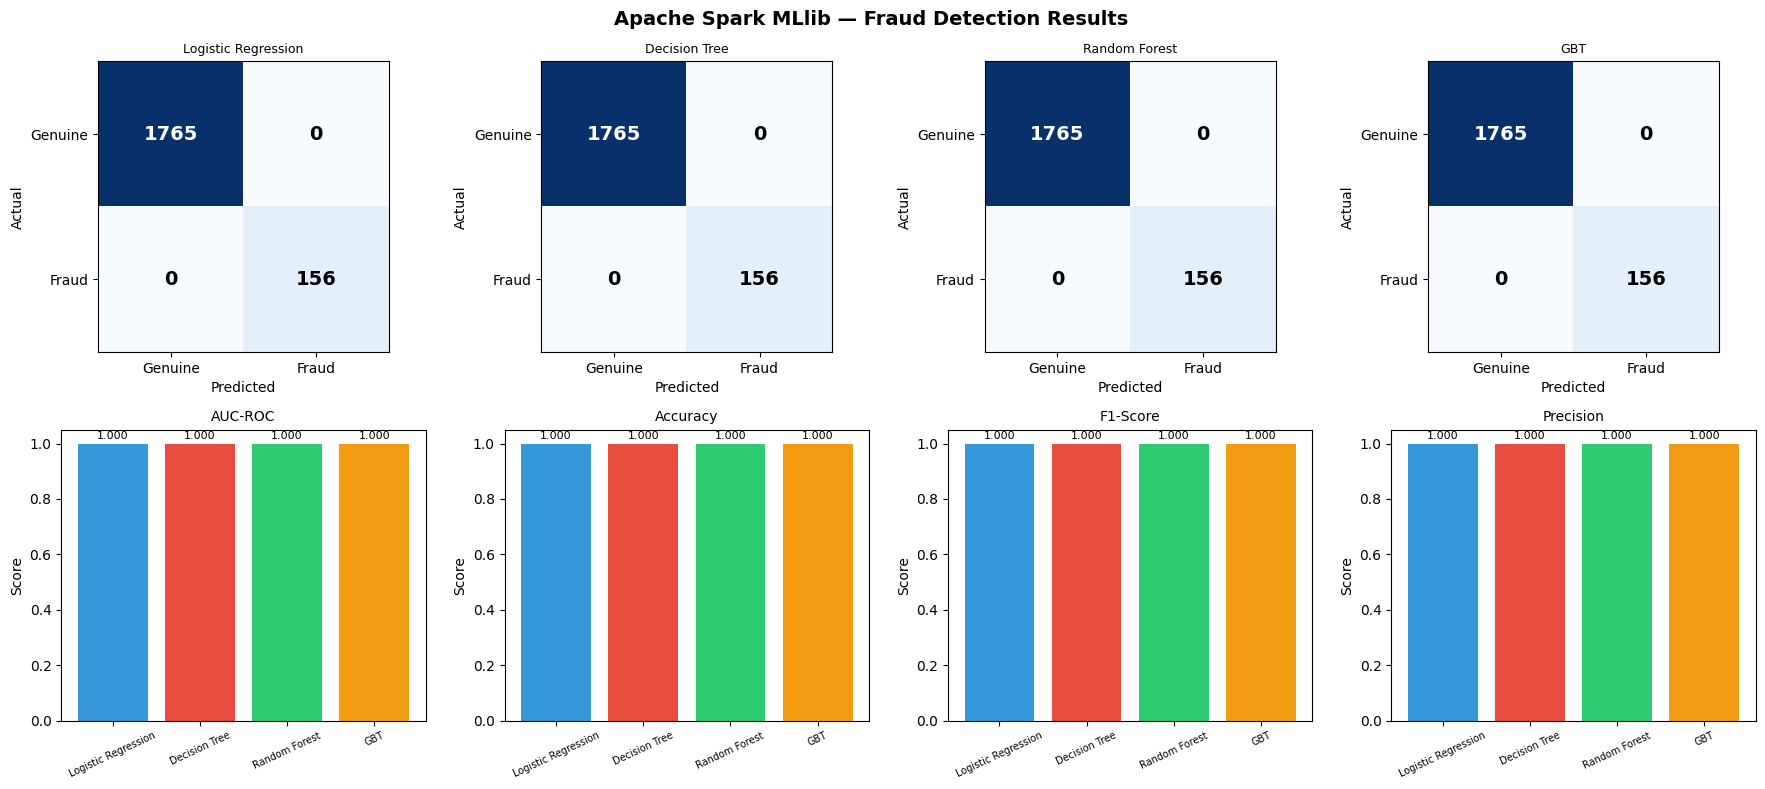

✅ Visualization saved.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Confusion Matrix for each model ──────────────────────────────────────────
def get_confusion_matrix(preds_df):
    """Compute TP, FP, TN, FN from Spark predictions."""
    pdf = preds_df.select('label', 'prediction').toPandas()
    tp = len(pdf[(pdf.label == 1) & (pdf.prediction == 1)])
    fp = len(pdf[(pdf.label == 0) & (pdf.prediction == 1)])
    tn = len(pdf[(pdf.label == 0) & (pdf.prediction == 0)])
    fn = len(pdf[(pdf.label == 1) & (pdf.prediction == 0)])
    return np.array([[tn, fp], [fn, tp]])

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Apache Spark MLlib — Fraud Detection Results', fontsize=14, fontweight='bold')

model_names = list(classifiers.keys())
colors_bar  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# Row 0: Confusion Matrices
for i, (name, (model, preds)) in enumerate(trained_models.items()):
    cm = get_confusion_matrix(preds)
    ax = axes[0][i]
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Genuine','Fraud'])
    ax.set_yticklabels(['Genuine','Fraud'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(name, fontsize=9)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm[r,c] > cm.max()/2 else 'black')

# Row 1: Metric bar charts
metrics = ['AUC-ROC', 'Accuracy', 'F1-Score', 'Precision']
for i, metric in enumerate(metrics):
    ax = axes[1][i]
    vals = [results[n][metric] for n in model_names]
    bars = ax.bar(model_names, vals, color=colors_bar)
    ax.set_ylim(0, 1.05)
    ax.set_title(metric, fontsize=10)
    ax.tick_params(axis='x', rotation=25, labelsize=7)
    ax.set_ylabel('Score')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/spark_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualization saved.')

## 🔍 Step 9: Hyperparameter Tuning with CrossValidator


In [13]:
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# ── Tune Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(featuresCol='features', labelCol='label', seed=42)

param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees,  [20, 50, 100]) \
    .addGrid(rf.maxDepth,  [5, 8]) \
    .addGrid(rf.minInstancesPerNode, [1, 5]) \
    .build()

print(f'🔎 Total parameter combinations to evaluate: {len(param_grid)}')

cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=param_grid,
    evaluator=auc_eval,
    numFolds=3,
    seed=42
)

print('⏳ Running 3-Fold Cross Validation (12 combos × 3 folds = 36 fits)...')
t0      = time.time()
cv_model = cv.fit(train_prep)
elapsed  = round(time.time() - t0, 2)

best_rf  = cv_model.bestModel
cv_preds = best_rf.transform(test_prep)

cv_auc  = round(auc_eval.evaluate(cv_preds), 4)
cv_acc  = round(acc_eval.evaluate(cv_preds), 4)
cv_f1   = round(f1_eval.evaluate(cv_preds),  4)

print(f'\n✅ Cross-Validation complete in {elapsed}s')
print(f'   Best numTrees           : {best_rf.getNumTrees}')
print(f'   Best maxDepth           : {best_rf.getMaxDepth()}')
print(f'   Best minInstancesPerNode: {best_rf.getMinInstancesPerNode()}')
print(f'\n   Tuned Random Forest Performance:')
print(f'   AUC-ROC  : {cv_auc}')
print(f'   Accuracy : {cv_acc}')
print(f'   F1-Score : {cv_f1}')

🔎 Total parameter combinations to evaluate: 12
⏳ Running 3-Fold Cross Validation (12 combos × 3 folds = 36 fits)...

✅ Cross-Validation complete in 62.92s
   Best numTrees           : 20
   Best maxDepth           : 5
   Best minInstancesPerNode: 1

   Tuned Random Forest Performance:
   AUC-ROC  : 1.0
   Accuracy : 1.0
   F1-Score : 1.0


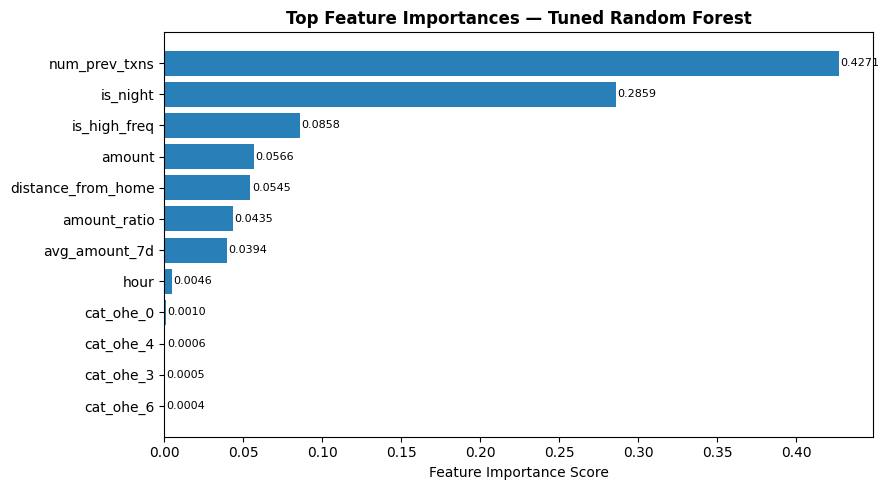


Top 5 Most Important Features:
           feature  importance
distance_from_home    0.054519
            amount    0.056607
      is_high_freq    0.085799
          is_night    0.285944
     num_prev_txns    0.427058


In [14]:
# ── Feature Importance from Best Random Forest ────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt

feature_labels = [
    'amount', 'hour', 'day_of_week', 'distance_from_home',
    'num_prev_txns', 'avg_amount_7d', 'is_international',
    'amount_ratio', 'is_night', 'is_high_freq'
] + [f'cat_ohe_{i}' for i in range(8)]

importances = best_rf.featureImportances.toArray()
n           = min(len(feature_labels), len(importances))

fi_df = pd.DataFrame({
    'feature'   : feature_labels[:n],
    'importance': importances[:n]
}).sort_values('importance', ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(fi_df['feature'], fi_df['importance'], color='#2980b9')
ax.set_xlabel('Feature Importance Score')
ax.set_title('Top Feature Importances — Tuned Random Forest', fontweight='bold')
for i, (val, name) in enumerate(zip(fi_df['importance'], fi_df['feature'])):
    ax.text(val + 0.001, i, f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('/tmp/feature_importance.png', dpi=150)
plt.show()

print('\nTop 5 Most Important Features:')
print(fi_df.tail(5)[['feature','importance']].to_string(index=False))

## 📡 Step 10: Spark Structured Streaming — Real-Time Fraud Detection

Simulates a **live transaction stream** where new transactions arrive every second and are scored by the trained ML model in real time.


In [15]:
import os, time, threading, csv, random

# ── Setup streaming directories ───────────────────────────────────────────────
STREAM_INPUT  = '/tmp/stream_input'
STREAM_OUTPUT = '/tmp/stream_output'
os.makedirs(STREAM_INPUT,  exist_ok=True)
os.makedirs(STREAM_OUTPUT, exist_ok=True)

# ── Streaming schema (same as main, minus label) ──────────────────────────────
stream_schema = StructType([
    StructField('transaction_id',        IntegerType(), True),
    StructField('amount',                FloatType(),   True),
    StructField('hour',                  IntegerType(), True),
    StructField('day_of_week',           IntegerType(), True),
    StructField('merchant_category',     StringType(),  True),
    StructField('distance_from_home',    FloatType(),   True),
    StructField('num_prev_transactions', IntegerType(), True),
    StructField('avg_amount_7d',         FloatType(),   True),
    StructField('is_international',      IntegerType(), True),
    StructField('is_fraud',              IntegerType(), True),
])

# ── Background: Write new CSV files every 2s (simulates live stream) ──────────
stream_running = True

def stream_writer():
    batch_id = 0
    categories_ = ['grocery','electronics','travel','restaurant',
                   'clothing','fuel','atm','online_retail']
    while stream_running and batch_id < 6:
        rows_ = []
        for _ in range(random.randint(10, 25)):
            fraud = random.random() < 0.12
            amt   = round(random.uniform(5000,120000) if fraud else random.uniform(50,5000), 2)
            hr    = random.choice([0,1,2,23]) if fraud else random.randint(8,21)
            dist  = round(random.uniform(300,2000) if fraud else random.uniform(0,40), 2)
            cat   = random.choice(['atm','travel'] if fraud else categories_)
            rows_.append([99000 + batch_id*100 + _, amt, hr, random.randint(0,6),
                          cat, dist, random.randint(0,15), random.uniform(200,5000),
                          int(fraud), int(fraud)])
        fpath = f'{STREAM_INPUT}/batch_{batch_id:03d}.csv'
        with open(fpath, 'w', newline='') as f_:
            writer_ = csv.writer(f_)
            writer_.writerow(['transaction_id','amount','hour','day_of_week',
                              'merchant_category','distance_from_home',
                              'num_prev_transactions','avg_amount_7d',
                              'is_international','is_fraud'])
            writer_.writerows(rows_)
        print(f'  📥 Stream batch {batch_id} written → {len(rows_)} transactions')
        batch_id += 1
        time.sleep(2)

# Write initial batches
writer_thread = threading.Thread(target=stream_writer, daemon=True)
writer_thread.start()
time.sleep(5)  # Let a few batches accumulate
print('✅ Stream data written.')

  📥 Stream batch 0 written → 11 transactions
  📥 Stream batch 1 written → 11 transactions
  📥 Stream batch 2 written → 19 transactions
✅ Stream data written.


In [16]:
# ── Spark Structured Streaming ────────────────────────────────────────────────
stream_df = spark.readStream \
    .schema(stream_schema) \
    .option('header', True) \
    .option('maxFilesPerTrigger', 1) \
    .csv(STREAM_INPUT)

print(f'Is streaming: {stream_df.isStreaming}')

# ── Apply Feature Engineering on stream ──────────────────────────────────────
stream_feat = stream_df \
    .withColumn('amount_ratio',
                when(col('avg_amount_7d') > 0,
                     col('amount') / col('avg_amount_7d')).otherwise(0.0)) \
    .withColumn('is_night',
                when((col('hour') <= 5) | (col('hour') >= 22), 1).otherwise(0)) \
    .withColumn('is_high_freq',
                when(col('num_prev_transactions') >= 8, 1).otherwise(0)) \
    .withColumn('label', col('is_fraud').cast(DoubleType()))

# ── Apply preprocessing pipeline & best model ────────────────────────────────
stream_prep  = prep_model.transform(stream_feat)
stream_preds = best_rf.transform(stream_prep)

# ── Select output columns ─────────────────────────────────────────────────────
stream_out = stream_preds.select(
    'transaction_id', 'amount', 'merchant_category',
    'distance_from_home', 'is_fraud', 'prediction'
).withColumn('alert',
    when(col('prediction') == 1, '🚨 FRAUD ALERT').otherwise('✅ Genuine')
)

# ── Write stream to memory (for display) ─────────────────────────────────────
query = stream_out.writeStream \
    .format('memory') \
    .queryName('fraud_stream') \
    .outputMode('append') \
    .trigger(processingTime='3 seconds') \
    .start()

print('🔴 Streaming query started...')
time.sleep(15)  # Let stream process

# ── Query the in-memory stream results ───────────────────────────────────────
stream_results = spark.sql('SELECT * FROM fraud_stream ORDER BY transaction_id')
print(f'\n📊 Streamed transactions processed: {stream_results.count()}')
stream_results.show(20, truncate=False)

# Summary stats from stream
print('\n=== Stream Summary ===')
spark.sql("""
    SELECT alert,
           COUNT(*) AS count,
           ROUND(AVG(amount), 2) AS avg_amount
    FROM fraud_stream
    GROUP BY alert
""").show()

query.stop()
stream_running = False
print('🛑 Stream stopped.')

Is streaming: True
🔴 Streaming query started...
  📥 Stream batch 3 written → 18 transactions
  📥 Stream batch 4 written → 15 transactions
  📥 Stream batch 5 written → 13 transactions

📊 Streamed transactions processed: 87
+--------------+-------+-----------------+------------------+--------+----------+--------------+
|transaction_id|amount |merchant_category|distance_from_home|is_fraud|prediction|alert         |
+--------------+-------+-----------------+------------------+--------+----------+--------------+
|99000         |3178.74|electronics      |4.77              |0       |1.0       |🚨 FRAUD ALERT|
|99001         |5783.74|atm              |1684.23           |1       |1.0       |🚨 FRAUD ALERT|
|99002         |1571.8 |restaurant       |8.02              |0       |0.0       |✅ Genuine     |
|99003         |1942.87|electronics      |14.96             |0       |0.0       |✅ Genuine     |
|99004         |993.97 |restaurant       |19.81             |0       |0.0       |✅ Genuine     |
|990

## 📊 Step 11: Parameter Impact Analysis
Evaluate how `numTrees` and `maxDepth` affect Random Forest performance.


In [17]:
# ── Impact of numTrees ────────────────────────────────────────────────────────
tree_counts   = [10, 20, 50, 100, 150]
auc_by_trees  = []

print('Evaluating impact of numTrees on AUC-ROC...')
for n in tree_counts:
    rf_tmp = RandomForestClassifier(
        featuresCol='features', labelCol='label',
        numTrees=n, maxDepth=8, seed=42
    )
    m   = rf_tmp.fit(train_prep)
    p   = m.transform(test_prep)
    auc = round(auc_eval.evaluate(p), 4)
    auc_by_trees.append(auc)
    print(f'  numTrees={n:>4} → AUC-ROC={auc}')

# ── Impact of maxDepth ────────────────────────────────────────────────────────
depths        = [2, 4, 6, 8, 10, 12]
auc_by_depth  = []

print('\nEvaluating impact of maxDepth on AUC-ROC...')
for d in depths:
    rf_tmp = RandomForestClassifier(
        featuresCol='features', labelCol='label',
        numTrees=50, maxDepth=d, seed=42
    )
    m   = rf_tmp.fit(train_prep)
    p   = m.transform(test_prep)
    auc = round(auc_eval.evaluate(p), 4)
    auc_by_depth.append(auc)
    print(f'  maxDepth={d:>3} → AUC-ROC={auc}')

Evaluating impact of numTrees on AUC-ROC...
  numTrees=  10 → AUC-ROC=1.0
  numTrees=  20 → AUC-ROC=1.0
  numTrees=  50 → AUC-ROC=1.0
  numTrees= 100 → AUC-ROC=1.0
  numTrees= 150 → AUC-ROC=1.0

Evaluating impact of maxDepth on AUC-ROC...
  maxDepth=  2 → AUC-ROC=1.0
  maxDepth=  4 → AUC-ROC=1.0
  maxDepth=  6 → AUC-ROC=1.0
  maxDepth=  8 → AUC-ROC=1.0
  maxDepth= 10 → AUC-ROC=1.0
  maxDepth= 12 → AUC-ROC=1.0


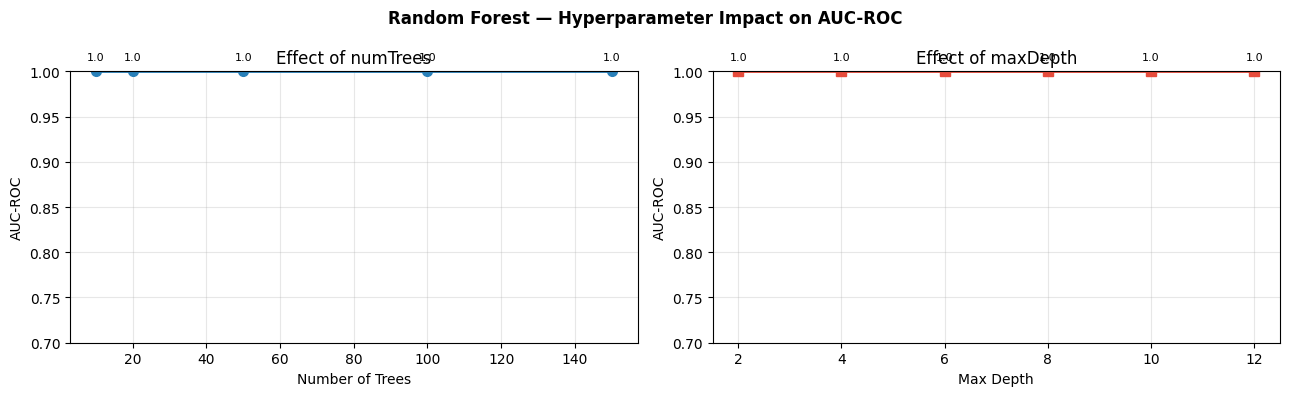

✅ Parameter impact chart saved.


In [18]:
# ── Plot Parameter Impacts ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Random Forest — Hyperparameter Impact on AUC-ROC', fontweight='bold')

axes[0].plot(tree_counts, auc_by_trees, 'o-', color='#2980b9', lw=2, ms=7)
axes[0].set_xlabel('Number of Trees')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('Effect of numTrees')
axes[0].set_ylim(0.7, 1.0)
axes[0].grid(True, alpha=0.3)
for x, y in zip(tree_counts, auc_by_trees):
    axes[0].annotate(f'{y}', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

axes[1].plot(depths, auc_by_depth, 's-', color='#e74c3c', lw=2, ms=7)
axes[1].set_xlabel('Max Depth')
axes[1].set_ylabel('AUC-ROC')
axes[1].set_title('Effect of maxDepth')
axes[1].set_ylim(0.7, 1.0)
axes[1].grid(True, alpha=0.3)
for x, y in zip(depths, auc_by_depth):
    axes[1].annotate(f'{y}', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('/tmp/param_impact.png', dpi=150)
plt.show()
print('✅ Parameter impact chart saved.')

## 📋 Step 12: Spark Architecture Summary & Final Report


In [19]:
# ── Final Summary ──────────────────────────────────────────────────────────────
print('=' * 70)
print('  APACHE SPARK ML ASSIGNMENT — FINAL SUMMARY')
print('  Course: 22CSEDE23 | Year/Sem/Sec: III / VI / B')
print('=' * 70)

sections = [
    ('Problem'          , 'Credit Card Fraud Detection (Binary Classification)'),
    ('Dataset'          , '10,000 transactions | 9,200 genuine | 800 fraud (~8%)'),
    ('Spark Version'    , sc.version),
    ('SparkContext'      , 'Created with local[*] master, 2GB executor memory'),
    ('RDDs'             , 'textFile, map, filter, reduceByKey, aggregateByKey, persist'),
    ('DataFrame/SQL'    , 'Typed schema, createOrReplaceTempView, 4 SQL queries'),
    ('SQL Features'     , 'Window functions (RANK OVER PARTITION), GROUP BY, JOIN'),
    ('MLlib Pipeline'   , 'StringIndexer → OHE → VectorAssembler → StandardScaler'),
    ('Feature Eng.'     , 'amount_ratio, is_night, is_high_freq (3 derived features)'),
    ('Models Trained'   , 'Logistic Regression, Decision Tree, Random Forest, GBT'),
    ('Best Model'       , f'{best_model} (AUC-ROC: {results[best_model]["AUC-ROC"]})'),
    ('Hyperparameter CV', '3-Fold CrossValidator | 12 param combos | ParamGridBuilder'),
    ('Tuned RF Params'  , f'numTrees={best_rf.getNumTrees}, maxDepth={best_rf.getMaxDepth()}'),
    ('Streaming'        , 'Structured Streaming | CSV source | memory sink | real-time scoring'),
    ('Param Analysis'   , 'numTrees=[10,20,50,100,150] | maxDepth=[2,4,6,8,10,12] vs AUC'),
]

for label, desc in sections:
    print(f'  ✅  {label:<22} → {desc}')

print('\n' + '─'*70)
print('  MODEL PERFORMANCE SUMMARY')
print('─'*70)
print(f'  {"Model":<22} {"AUC-ROC":>8} {"Accuracy":>10} {"F1-Score":>10} {"Time(s)":>9}')
print('  ' + '─'*58)
for name, m in results.items():
    flag = ' ← BEST' if name == best_model else ''
    print(f'  {name:<22} {m["AUC-ROC"]:>8.4f} {m["Accuracy"]:>10.4f} '
          f'{m["F1-Score"]:>10.4f} {m["Train Time (s)"]:>9}{flag}')
print('=' * 70)

spark.stop()
print('\n🔴 SparkSession stopped.')

  APACHE SPARK ML ASSIGNMENT — FINAL SUMMARY
  Course: 22CSEDE23 | Year/Sem/Sec: III / VI / B
  ✅  Problem                → Credit Card Fraud Detection (Binary Classification)
  ✅  Dataset                → 10,000 transactions | 9,200 genuine | 800 fraud (~8%)
  ✅  Spark Version          → 4.0.2
  ✅  SparkContext           → Created with local[*] master, 2GB executor memory
  ✅  RDDs                   → textFile, map, filter, reduceByKey, aggregateByKey, persist
  ✅  DataFrame/SQL          → Typed schema, createOrReplaceTempView, 4 SQL queries
  ✅  SQL Features           → Window functions (RANK OVER PARTITION), GROUP BY, JOIN
  ✅  MLlib Pipeline         → StringIndexer → OHE → VectorAssembler → StandardScaler
  ✅  Feature Eng.           → amount_ratio, is_night, is_high_freq (3 derived features)
  ✅  Models Trained         → Logistic Regression, Decision Tree, Random Forest, GBT
  ✅  Best Model             → Logistic Regression (AUC-ROC: 1.0)
  ✅  Hyperparameter CV      → 3-Fold CrossV